In [1]:
import qiskit
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import SparsePauliOp

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler, EstimatorV2 as Estimator
from qiskit.primitives import StatevectorSampler
from qiskit_aer import AerSimulator
import numpy as np

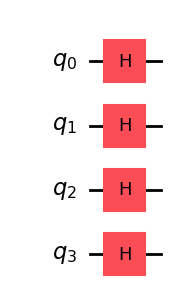

In [2]:
qc = QuantumCircuit(4)
qc.h((0,1,2,3))
qc.draw('mpl')

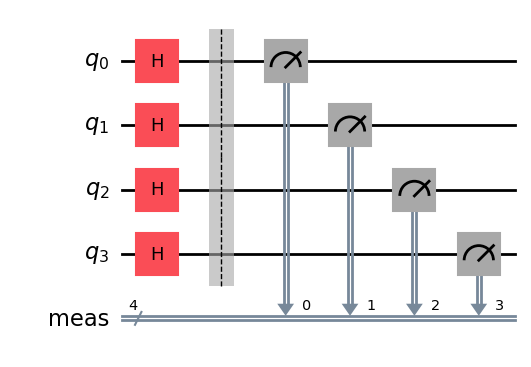

In [3]:
qc.measure_all()
qc.draw('mpl')

In [4]:
def random_no_gen(req_num = 1):
  qc = QuantumCircuit(1)
  qc.h((0))#applying H gate to all the qbits
  qc.measure_all()
  R = []
  for _ in range(req_num):
    r = []
    for _ in range(4):
      sampler = StatevectorSampler(default_shots=1) # measusing ones to get one of the 15 numbers with probability 1/16
      pub = qc
      job_sampler = sampler.run([pub])


      result_sampler = job_sampler.result()
      counts_sampler = result_sampler[0].data.meas.get_counts()
      r.append(list(counts_sampler.keys())[0])
    c = 0
    res = 0
    for i in r:
      if i == '1':
        res += 2**c
      c+=1
    R.append(res)
  if req_num == 1:
    return R[0]
  else:
    return np.array(R),qc

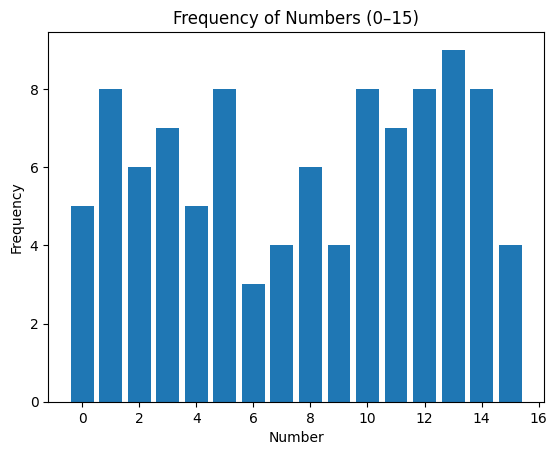

In [5]:
import matplotlib.pyplot as plt
from collections import Counter
values,qc = random_no_gen(100)


# Count how many times each number appears
counts = Counter(values)

# Sort by number (optional, for a nicer plot)
numbers = sorted(counts.keys())
frequencies = [counts[n] for n in numbers]

# Create the bar plot
plt.bar(numbers, frequencies)
plt.xlabel('Number')
plt.ylabel('Frequency')
plt.title('Frequency of Numbers (0–15)')
plt.show()